# Employment by Industry Exploratory Data Analysis (EDA)

This notebook provides a reusable EDA workflow for the cleaned employment-by-industry dataset.

**Default dataset:** data/clean/employment_by_industry_20y+keys.csv

**Objectives:**
- inspect the structure of the dataset
- reshape quarterly employment values into a tidy time series
- analyze long-run employment trends by industry and category
- check correlation, nonlinearity, heterogeneity, and subgroup differences

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# Resolve the dataset path robustly after moving the notebook into a deeper subfolder
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
dataset_path = None

for root in candidate_roots:
    candidate = root / "data" / "clean" / "employment_by_industry_20y+keys.csv"
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    raise FileNotFoundError(f"Could not locate the employment-by-industry dataset from working directory: {Path.cwd()}")

df = pd.read_csv(dataset_path)

print(f"Loaded {dataset_path.name}")
print(f"Resolved path: {dataset_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
display(df.head())

Loaded employment_by_industry_20y+keys.csv
Resolved path: c:\Users\neddp\ECC3479-Project-JRGS\data\clean\employment_by_industry_20y+keys.csv
Rows: 19 | Columns: 84


,Industry,Category,CategoryKey,Nov-05,Feb-06,May-06,Aug-06,Nov-06,Feb-07,May-07,Aug-07,Nov-07,Feb-08,May-08,Aug-08,Nov-08,Feb-09,May-09,Aug-09,Nov-09,Feb-10,May-10,Aug-10,Nov-10,Feb-11,May-11,Aug-11,Nov-11,Feb-12,May-12,Aug-12,Nov-12,Feb-13,May-13,Aug-13,Nov-13,Feb-14,May-14,Aug-14,Nov-14,Feb-15,May-15,Aug-15,Nov-15,Feb-16,May-16,Aug-16,Nov-16,Feb-17,May-17,Aug-17,Nov-17,Feb-18,May-18,Aug-18,Nov-18,Feb-19,May-19,Aug-19,Nov-19,Feb-20,May-20,Aug-20,Nov-20,Feb-21,May-21,Aug-21,Nov-21,Feb-22,May-22,Aug-22,Nov-22,Feb-23,May-23,Aug-23,Nov-23,Feb-24,May-24,Aug-24,Nov-24,Feb-25,May-25,Aug-25,Nov-25
0,"Agriculture, Forestry and Fishing",Environment & Related,5,349400,348100,347100,346400,345900,345700,345600,345700,345900,346100,346300,346400,346400,346200,345600,344800,343600,342000,340000,337700,335100,332200,329200,326300,323500,321000,318600,316400,314600,313100,312100,311500,311200,311200,311400,311600,312000,312400,312900,313500,314300,315300,316300,317500,318800,320400,322000,323700,325300,326900,328200,329400,330300,331000,331500,331700,331700,331400,330900.0,330000.0,328600.0,326900.0,325000.0,322800.0,320600.0,318400,316300,314400,312700,311200,309800,308500,307200,305700,303900,301700,299100,296100,292800,289300,285500
1,Mining,Engineering & Related Tech,3,119300,122600,125900,129100,132300,135600,139000,142500,146100,150000,154000,158200,162600,167100,171900,177000,182400,188300,194400,200900,207500,214200,220800,227100,233000,238300,242800,246400,249000,250500,251100,250800,249700,247900,245500,242800,240000,237200,234700,232600,230900,229700,229200,229200,229900,231200,233000,235200,237900,240800,244000,247400,250700,254100,257400,260700,264100,267500,271000.0,274600.0,278200.0,281900.0,285500.0,289000.0,292300.0,295400,298100,300400,302400,304000,305200,305900,306300,306200,305800,305100,304200,302900,301300,299500,297500
2,Manufacturing,Engineering & Related Tech,3,1016900,1014100,1012500,1012600,1015200,1021000,1029100,1037600,1045300,1049500,1047300,1039400,1028300,1017100,1007200,999600,992700,986900,981300,976700,971300,964100,955900,949100,945900,944800,943900,942400,938900,933300,928500,926100,925500,924200,921700,918400,913800,907900,900300,892500,888400,889900,894100,899300,904000,902900,899600,898700,903300,911900,918300,917100,908400,898700,892900,889000,886700,882200,875900.0,872600.0,874700.0,882200.0,888500.0,887600.0,877100.0,865600,858900,859900,867900,880000,893900,904800,909400,907500,901100,892800,884600,877200,871300,868400,869100
3,"Electricity, Gas, Water and Waste Services",Engineering & Related Tech,3,100800,102500,104200,106000,107900,109800,111800,113900,116100,118300,120500,122700,124900,127000,129100,131100,133000,134800,136500,138100,139500,140800,141900,142900,143700,144400,144900,145200,145500,145600,145700,145700,145500,145400,145200,145000,144700,144500,144300,144100,143900,143800,143800,143800,143900,144200,144500,144800,145300,145700,146200,146800,147300,147900,148500,149100,149700,150500,151200.0,152100.0,153100.0,154300.0,155600.0,157100.0,158800.0,160800,163000,165400,168100,171000,174200,177700,181400,185300,189500,193800,198300,202900,207500,212300,217200
4,Construction,Architecture & Building,4,858900,872300,886000,900400,914700,925500,932900,940600,951800,963800,972500,978300,981900,982900,981500,979700,980500,984200,988900,993900,1000300,1005000,1007100,1004600,999300,992100,984700,980700,983500,989600,995400,1001500,1007100,1013700,1020200,1025600,1029800,1032100,1034600,1038200,1044700,1053000,1061800,1071400,1085600,1104600,1124500,1143200,1158700,1169200,1172900,1172800,1171300,1171400,1173600,1175900,1177400,1176100,1171100.0,1164300.0,1158000.0,1151900.0,1147900.0,1148800.0,1159700.0,1180500,1209000,1242100,1272800,1296500,1311600,1321000,1328600,1334100,1338800,1342500,1348100,1351400,1351300,1353700,1360000


## 1. Inspect Data Structure and Reshape the Time Series

Review the columns, identify the quarterly employment fields, and reshape the dataset into long format for analysis.

In [2]:
print("Column names:")
print(df.columns.tolist())

id_cols = ["Industry", "Category", "CategoryKey"]
period_cols = [col for col in df.columns if col not in id_cols]

for col in period_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

employment_long = df.melt(
    id_vars=id_cols,
    value_vars=period_cols,
    var_name="PeriodLabel",
    value_name="Employment",
)
employment_long["Period"] = pd.to_datetime(employment_long["PeriodLabel"], format="%b-%y", errors="coerce")
employment_long["Year"] = employment_long["Period"].dt.year

print(f"\nDetected time columns: {len(period_cols)}")
print(f"First 5 time columns: {period_cols[:5]}")
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nWide shape: {df.shape}")
print(f"Long shape: {employment_long.shape}")
display(employment_long.head())

Column names:
['Industry', 'Category', 'CategoryKey', 'Nov-05', 'Feb-06', 'May-06', 'Aug-06', 'Nov-06', 'Feb-07', 'May-07', 'Aug-07', 'Nov-07', 'Feb-08', 'May-08', 'Aug-08', 'Nov-08', 'Feb-09', 'May-09', 'Aug-09', 'Nov-09', 'Feb-10', 'May-10', 'Aug-10', 'Nov-10', 'Feb-11', 'May-11', 'Aug-11', 'Nov-11', 'Feb-12', 'May-12', 'Aug-12', 'Nov-12', 'Feb-13', 'May-13', 'Aug-13', 'Nov-13', 'Feb-14', 'May-14', 'Aug-14', 'Nov-14', 'Feb-15', 'May-15', 'Aug-15', 'Nov-15', 'Feb-16', 'May-16', 'Aug-16', 'Nov-16', 'Feb-17', 'May-17', 'Aug-17', 'Nov-17', 'Feb-18', 'May-18', 'Aug-18', 'Nov-18', 'Feb-19', 'May-19', 'Aug-19', 'Nov-19', 'Feb-20', 'May-20', 'Aug-20', 'Nov-20', 'Feb-21', 'May-21', 'Aug-21', 'Nov-21', 'Feb-22', 'May-22', 'Aug-22', 'Nov-22', 'Feb-23', 'May-23', 'Aug-23', 'Nov-23', 'Feb-24', 'May-24', 'Aug-24', 'Nov-24', 'Feb-25', 'May-25', 'Aug-25', 'Nov-25']

Detected time columns: 81
First 5 time columns: ['Nov-05', 'Feb-06', 'May-06', 'Aug-06', 'Nov-06']

Data types:


,dtype
Industry,str
Category,str
CategoryKey,int64
Nov-05,int64
Feb-06,int64
...,...
Nov-24,int64
Feb-25,int64
May-25,int64
Aug-25,int64



Wide shape: (19, 84)
Long shape: (1539, 7)


,Industry,Category,CategoryKey,PeriodLabel,Employment,Period,Year
0,"Agriculture, Forestry and Fishing",Environment & Related,5,Nov-05,349400.0,2005-11-01,2005
1,Mining,Engineering & Related Tech,3,Nov-05,119300.0,2005-11-01,2005
2,Manufacturing,Engineering & Related Tech,3,Nov-05,1016900.0,2005-11-01,2005
3,"Electricity, Gas, Water and Waste Services",Engineering & Related Tech,3,Nov-05,100800.0,2005-11-01,2005
4,Construction,Architecture & Building,4,Nov-05,858900.0,2005-11-01,2005


## 2. Clean Missing Values and Compute Summary Statistics

Check for missing values and duplicates, then summarize employment by category and industry.

In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
display(missing_summary.to_frame("missing_count") if not missing_summary.empty else pd.DataFrame({"message": ["No missing values found"]}))

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
employment_long_clean = employment_long.dropna(subset=["Period", "Employment"]).copy()

category_stats = (
    employment_long_clean.groupby("Category")["Employment"]
    .agg(["mean", "std", "min", "max", "count"])
    .sort_values("mean", ascending=False)
)

latest_period = employment_long_clean["Period"].max()
latest_snapshot = (
    employment_long_clean[employment_long_clean["Period"] == latest_period]
    [["Industry", "Category", "Employment"]]
    .sort_values("Employment", ascending=False)
)

print(f"\nLatest period in the dataset: {latest_period.strftime('%b-%Y')}")
display(category_stats)
display(latest_snapshot.head(10))

Missing values by column:


,missing_count
May-20,5
Aug-20,4
Nov-20,4
Feb-21,2
Aug-21,2
May-21,2
Nov-21,2


Duplicate rows: 0

Latest period in the dataset: Nov-2025


,mean,std,min,max,count
Category,,,,,
Health,1.568648e+06,392961.457433,1013900.0,2391600.0,81
Architecture & Building,1.093433e+06,136767.594846,858900.0,1360000.0,81
Natural & Physical Science,1.008038e+06,196208.846365,701700.0,1376100.0,81
Education,9.698642e+05,157779.640883,730400.0,1305800.0,81
Society & Culture,7.756370e+05,107418.937395,612200.0,991400.0,81
Management & Commerce,5.849752e+05,327259.377356,185500.0,1343700.0,556
Others,4.816808e+05,38479.821184,407000.0,569500.0,78
Engineering & Related Tech,4.380070e+05,354452.257553,100800.0,1049500.0,243
Environment & Related,3.241704e+05,15591.058691,285500.0,349400.0,81


,Industry,Category,Employment
1536,Health Care and Social Assistance,Health,2391600.0
1532,"Professional, Scientific and Technical Services",Natural & Physical Science,1376100.0
1524,Construction,Architecture & Building,1360000.0
1526,Retail Trade,Management & Commerce,1343700.0
1535,Education and Training,Education,1305800.0
1534,Public Administration and Safety,Society & Culture,991400.0
1527,Accommodation and Food Services,Management & Commerce,981100.0
1522,Manufacturing,Engineering & Related Tech,869100.0
1528,"Transport, Postal and Warehousing",Management & Commerce,739400.0
1538,Other Services,Others,569500.0


## 3. Visualize Employment Trends

Plot overall employment, category-level time trends, and the latest industry rankings.

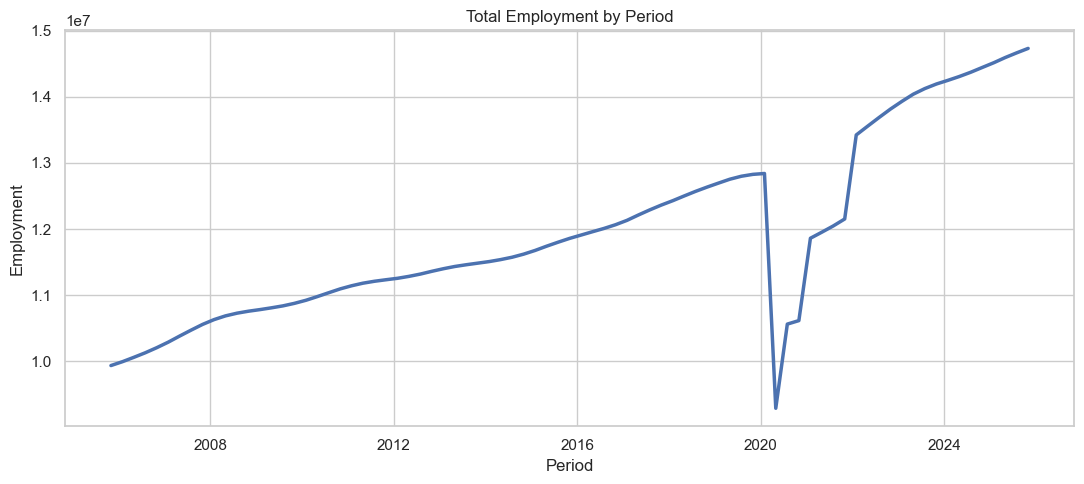

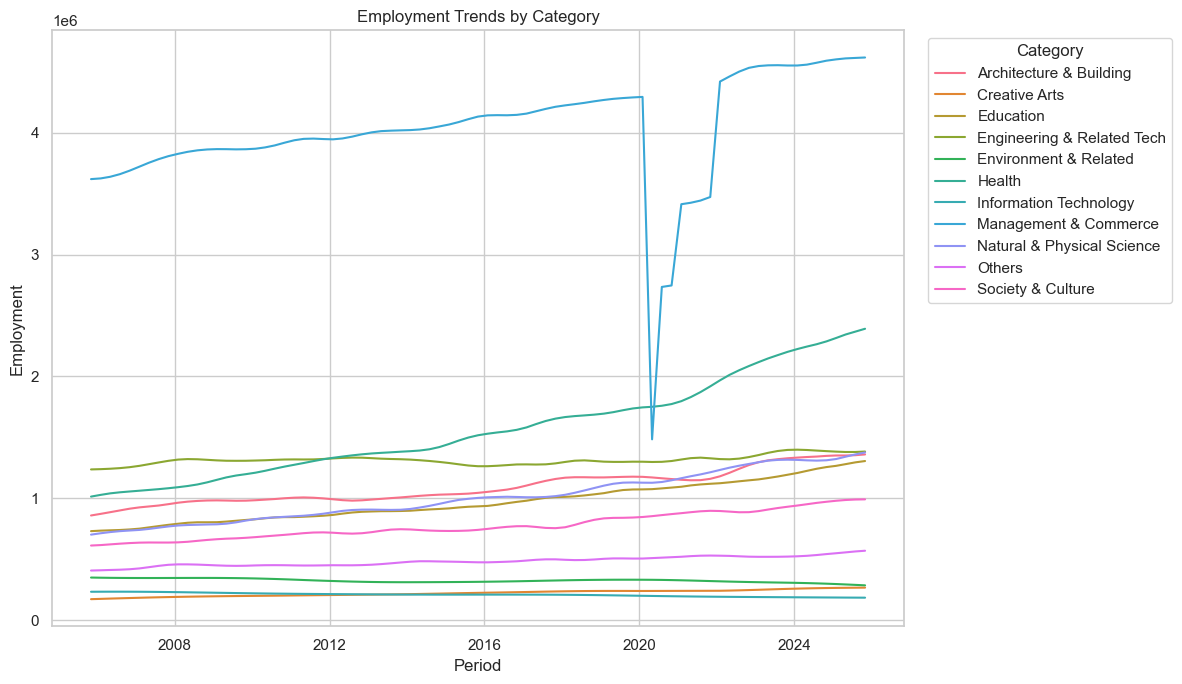

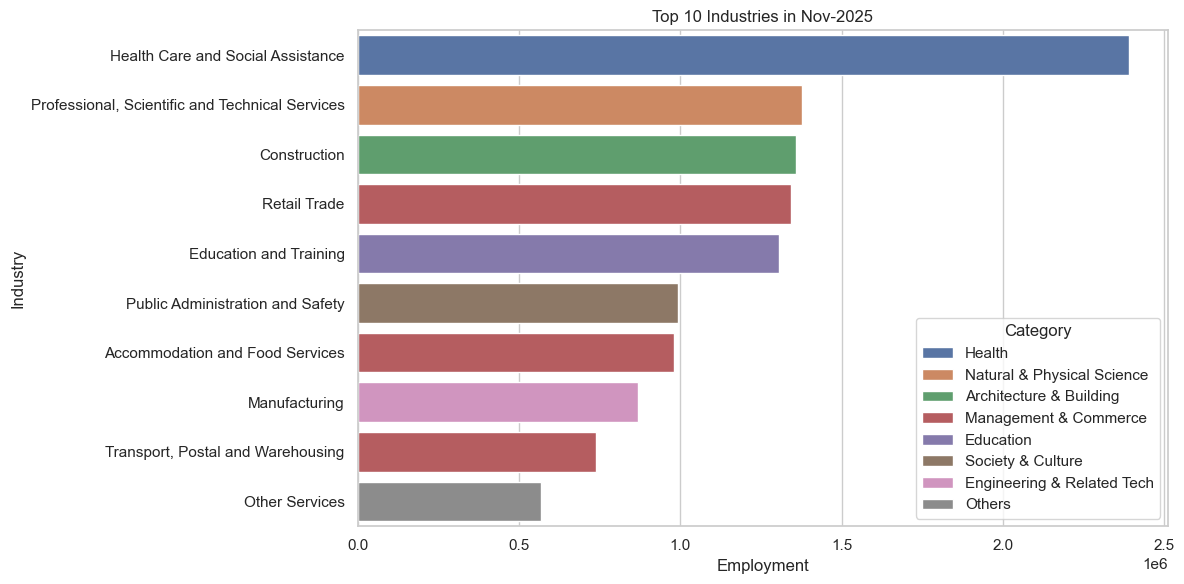

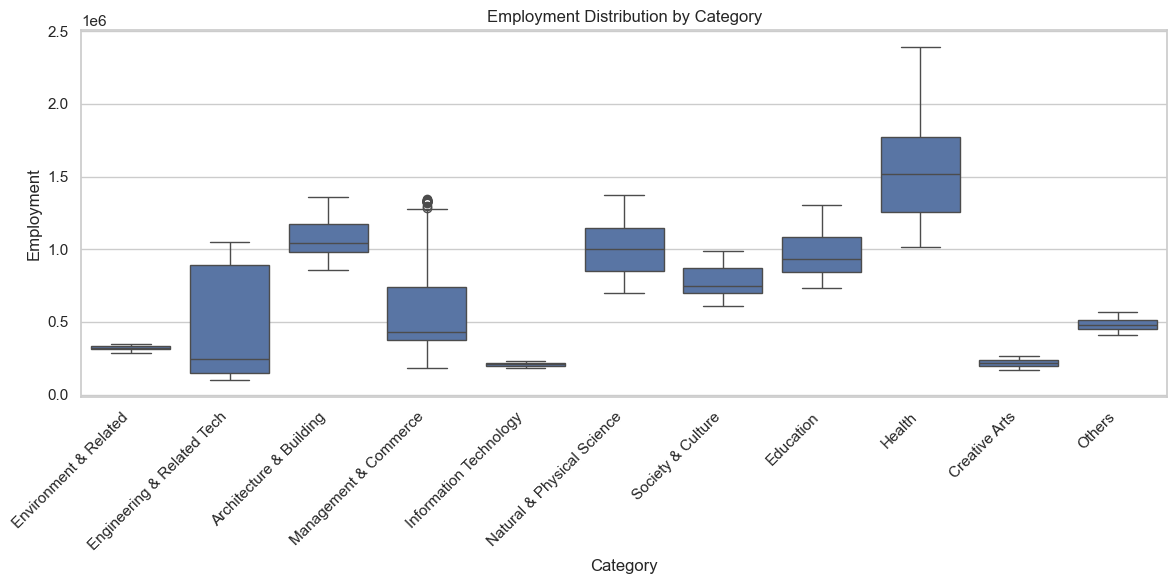

In [4]:
overall_employment = (
    employment_long_clean.groupby("Period", as_index=False)["Employment"]
    .sum()
    .sort_values("Period")
)

category_over_time = (
    employment_long_clean.groupby(["Period", "Category"], as_index=False)["Employment"]
    .sum()
    .sort_values(["Period", "Category"])
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=overall_employment, x="Period", y="Employment", linewidth=2.5)
plt.title("Total Employment by Period")
plt.xlabel("Period")
plt.ylabel("Employment")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.lineplot(data=category_over_time, x="Period", y="Employment", hue="Category")
plt.title("Employment Trends by Category")
plt.xlabel("Period")
plt.ylabel("Employment")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=latest_snapshot.head(10), x="Employment", y="Industry", hue="Category")
plt.title(f"Top 10 Industries in {latest_period.strftime('%b-%Y')}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=employment_long_clean, x="Category", y="Employment")
plt.title("Employment Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Employment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Additional Statistical Checks

This section checks for correlation, nonlinearity, heterogeneity, and subgroup differences in employment by industry.

In [8]:
try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_df = (
    employment_long_clean.groupby(['Year', 'Category'], as_index=False)['Employment']
    .mean()
    .sort_values(['Year', 'Category'])
)

yearly_total = (
    analysis_df.groupby('Year', as_index=False)['Employment']
    .sum()
    .sort_values('Year')
)

pearson_year_total = yearly_total[['Year', 'Employment']].corr(method='pearson').iloc[0, 1]
spearman_year_total = yearly_total[['Year', 'Employment']].corr(method='spearman').iloc[0, 1]

print(f'Pearson correlation between Year and total employment: {pearson_year_total:.4f}')
print(f'Spearman correlation between Year and total employment: {spearman_year_total:.4f}')

category_corr = (
    analysis_df.groupby('Category')
    .apply(lambda g: g['Year'].corr(g['Employment']) if g['Year'].nunique() > 1 else np.nan)
    .reset_index(name='Year_vs_Employment_corr')
    .sort_values('Year_vs_Employment_corr', ascending=False)
)

print('Category-level correlation between Year and employment')
display(category_corr)

Pearson correlation between Year and total employment: 0.9833
Spearman correlation between Year and total employment: 1.0000
Category-level correlation between Year and employment


,Category,Year_vs_Employment_corr
1,Creative Arts,0.993766
8,Natural & Physical Science,0.991656
2,Education,0.988946
10,Society & Culture,0.982835
5,Health,0.980856
9,Others,0.975862
0,Architecture & Building,0.967396
7,Management & Commerce,0.860032
3,Engineering & Related Tech,0.668458
4,Environment & Related,-0.788628


Linear fit R^2: 0.9668
Quadratic fit R^2: 0.9870
There is evidence of nonlinearity because the quadratic fit improves noticeably.


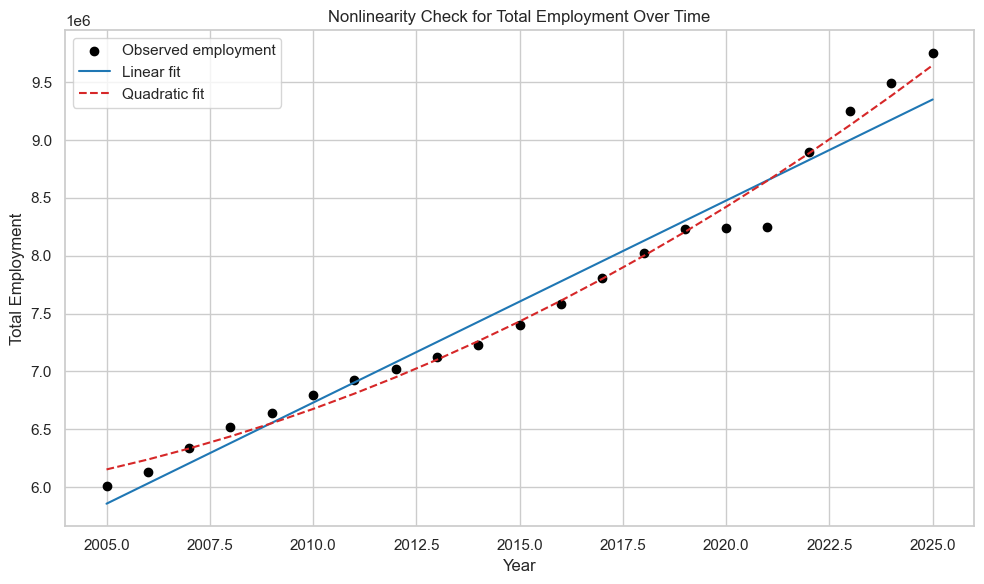

In [9]:
# Nonlinearity check: linear vs quadratic trend in total employment
x = yearly_total['Year'].to_numpy(dtype=float)
y = yearly_total['Employment'].to_numpy(dtype=float)

lin_coef = np.polyfit(x, y, 1)
quad_coef = np.polyfit(x, y, 2)
lin_pred = np.polyval(lin_coef, x)
quad_pred = np.polyval(quad_coef, x)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y, lin_pred)
quad_r2 = r2_score(y, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity because the quadratic fit improves noticeably.')
else:
    print('The employment trend appears mostly linear over time.')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed employment')
plt.plot(x, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check for Total Employment Over Time')
plt.xlabel('Year')
plt.ylabel('Total Employment')
plt.legend()
plt.tight_layout()
plt.show()

Variation in employment by category


,mean,std,min,max,count,cv
Category,,,,,,
Health,1.548836e+06,406264.054185,1.013900e+06,2.354975e+06,21,0.262303
Natural & Physical Science,9.970976e+05,204349.399605,7.017000e+05,1.349925e+06,21,0.204944
Education,9.613119e+05,163932.332766,7.304000e+05,1.286850e+06,21,0.170530
Architecture & Building,1.085057e+06,143407.508769,8.589000e+05,1.354100e+06,21,0.132166
Society & Culture,7.698000e+05,111501.055208,6.122000e+05,9.867500e+05,21,0.144844
Management & Commerce,5.818920e+05,42402.699058,5.171429e+05,6.588000e+05,21,0.072870
Others,4.798643e+05,40424.236674,4.070000e+05,5.595750e+05,21,0.084241
Creative Arts,2.192912e+05,27234.363301,1.720000e+05,2.656500e+05,20,0.124193
Environment & Related,3.250714e+05,16208.619014,2.909250e+05,3.494000e+05,21,0.049862


Levene's test for equal variances: statistic=23.6714, p-value=7.002e-30
One-way ANOVA across categories: statistic=149.3183, p-value=6.11e-92
Kruskal-Wallis test across categories: statistic=216.9871, p-value=4.565e-41
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


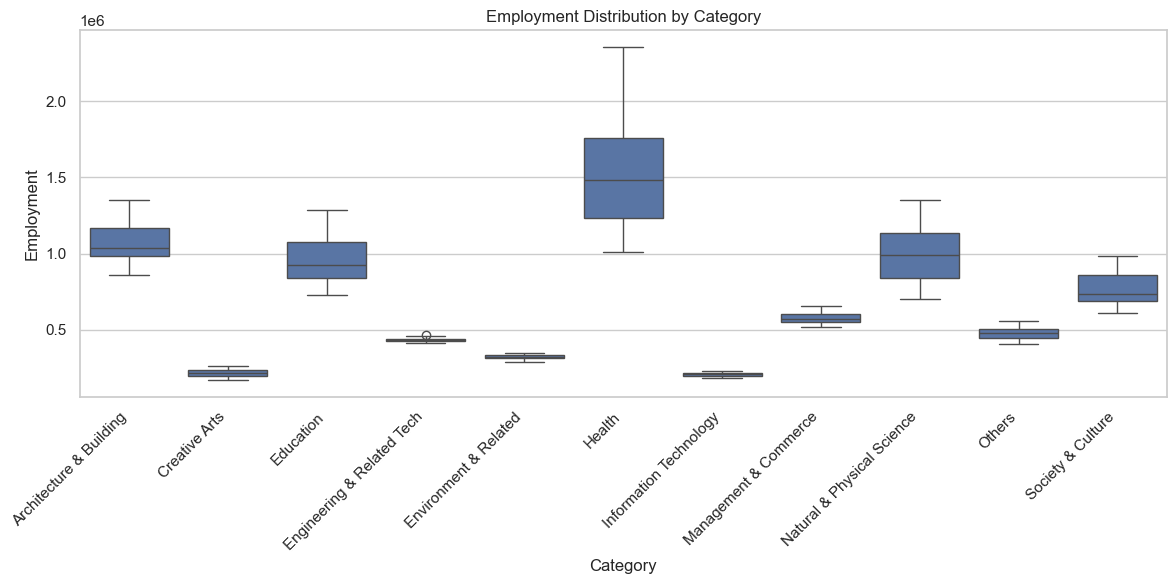

In [10]:
# Heterogeneity and subgroup difference checks
category_variation = (
    analysis_df.groupby('Category')['Employment']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
category_variation['cv'] = category_variation['std'] / category_variation['mean']

print('Variation in employment by category')
display(category_variation)

groups = [grp['Employment'].values for _, grp in analysis_df.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=analysis_df, x='Category', y='Employment')
plt.title('Employment Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Employment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mean employment: 694,285
Median employment: 574,907
Standard deviation: 430,552
IQR: 639,006 (Q1=345,219, Q3=984,225)
Skewness: 1.108


,Employment
count,2.300000e+02
mean,6.942852e+05
std,4.305523e+05
min,1.720000e+05
25%,3.452188e+05
50%,5.749071e+05
75%,9.842250e+05
max,2.354975e+06


,MedianEmployment
Category,
Health,1.483725e+06
Architecture & Building,1.037400e+06
Natural & Physical Science,9.892500e+05
Education,9.264750e+05
Society & Culture,7.377750e+05
Management & Commerce,5.734036e+05
Others,4.783250e+05
Engineering & Related Tech,4.362667e+05
Environment & Related,3.238250e+05


,Count
EmploymentBand,
Lower band,38
Middle band,59
Upper band,81
Highest band,52


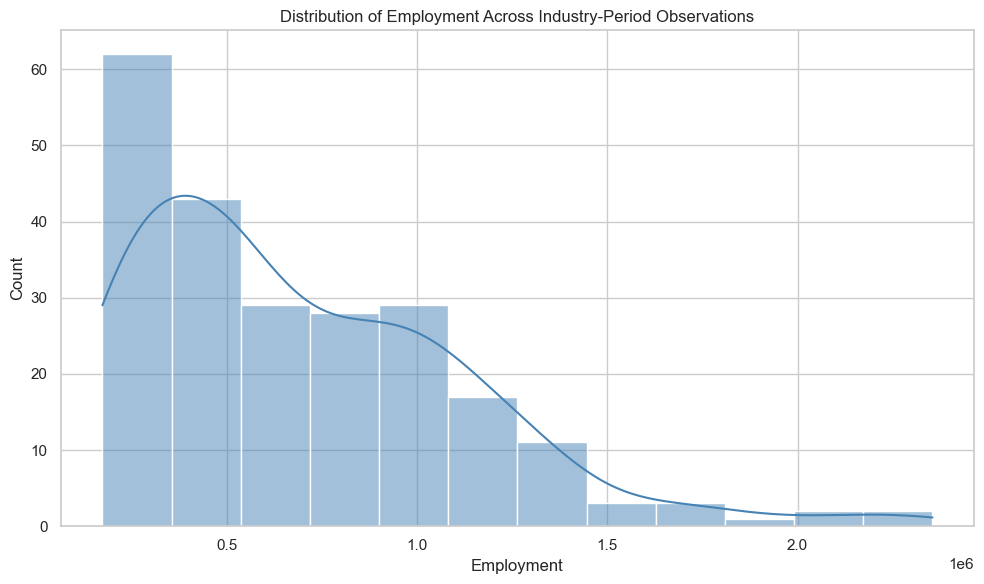

In [11]:
# Structure diagnostics: typical values, spread, skewness, and clumps
structure_df = analysis_df.copy()

summary_stats = structure_df['Employment'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('Employment')
q1 = structure_df['Employment'].quantile(0.25)
median = structure_df['Employment'].median()
q3 = structure_df['Employment'].quantile(0.75)
iqr = q3 - q1
mean_val = structure_df['Employment'].mean()
std_val = structure_df['Employment'].std()
skewness = structure_df['Employment'].skew()

print(f'Mean employment: {mean_val:,.0f}')
print(f'Median employment: {median:,.0f}')
print(f'Standard deviation: {std_val:,.0f}')
print(f'IQR: {iqr:,.0f} (Q1={q1:,.0f}, Q3={q3:,.0f})')
print(f'Skewness: {skewness:.3f}')

category_medians = (
    structure_df.groupby('Category')['Employment']
    .median()
    .sort_values(ascending=False)
    .to_frame('MedianEmployment')
)

structure_df['EmploymentBand'] = pd.cut(
    structure_df['Employment'],
    bins=[0, 250000, 500000, 1000000, np.inf],
    labels=['Lower band', 'Middle band', 'Upper band', 'Highest band'],
    include_lowest=True,
)

band_counts = structure_df['EmploymentBand'].value_counts().sort_index().to_frame('Count')

display(summary_stats)
display(category_medians)
display(band_counts)

plt.figure(figsize=(10, 6))
sns.histplot(structure_df['Employment'], bins=12, kde=True, color='steelblue')
plt.title('Distribution of Employment Across Industry-Period Observations')
plt.xlabel('Employment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** Employment values show a **wide spread**, with a mean of about **694,285**, a median of about **574,907**, and a standard deviation of about **430,552**. The interquartile range is about **639,006**, which shows that the middle half of observations is highly dispersed.
- **Typical values and clumps:** Many observations cluster in the **middle-to-upper employment ranges**, while a smaller set of categories sits well above **1 million**. This creates visible **clumping**, with **Health**, **Architecture & Building**, **Natural & Physical Science**, and **Education** standing out as especially large.
- **Skewness:** The employment distribution is **positively skewed** with skewness around **1.108**, meaning the upper tail contains some substantially larger industry-period observations than the typical case.
- **Trend over time:** Employment by industry rises strongly overall, with Pearson correlation about **0.9833** and Spearman correlation **1.0000** between year and total employment. The quadratic model fits slightly better than the linear one, with $R^2 \approx 0.9870$ versus $R^2 \approx 0.9668$, indicating **some nonlinearity** and a recovery pattern after the pandemic disruption.
- **Heterogeneity and subgroup differences:** Levene’s test, ANOVA, and Kruskal-Wallis are all highly significant, with $p \approx 7.002 \times 10^{-30}$, $p \approx 6.11 \times 10^{-92}$, and $p \approx 4.565 \times 10^{-41}$ respectively. This confirms strong differences in both scale and variability across categories.

### Overall interpretation

Employment has grown across the economy, but the structure of the data shows that this growth is not uniform. Instead, industries cluster at different scales, with a clear upper tail of very large categories and strong differences in how employment has changed over time.

## Data Characteristics & First-Order Effects

**Variables:** `Industry` (19 ABS industry categories), `Category` (mapped FOE groupings), `Employment` (employed persons in thousands, ABS Labour Force Survey). Data is stored in wide quarterly format (columns like `Nov-05`) and reshaped to long format for analysis. Values represent stock (employed persons) not flow (new hires or vacancies).

**Data cleaning:** 7 employment values are missing during 2020–2021 — this missingness is *systematic*, caused by ABS COVID-period collection disruptions, not random. These must be handled explicitly (not listwise-deleted) in any modelling step. No other missing values exist.

The analysis below tests whether employment counts require log transformation and whether the aggregate Year–Employment trend conceals within-industry contractions (Simpson's Paradox).

In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

df = pd.read_csv(clean_dir / 'employment_by_industry_20y+keys.csv')
id_cols = ['Industry', 'Category', 'CategoryKey']
period_cols = [c for c in df.columns if c not in id_cols]
for c in period_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

emp_long = df.melt(id_vars=id_cols, value_vars=period_cols, var_name='PeriodLabel', value_name='Employment')
emp_long['Period'] = pd.to_datetime(emp_long['PeriodLabel'], format='%b-%y', errors='coerce')
emp_long['Year'] = emp_long['Period'].dt.year
emp_long = emp_long.dropna(subset=['Period'])

# Annual average per category
cat_year = emp_long.groupby(['Year', 'Category'])['Employment'].mean().reset_index().dropna()

missing_n = emp_long['Employment'].isnull().sum()
print("=== Employment by Industry — Variable Summary ===")
print(f"Industries: {df['Industry'].nunique()}  |  Categories: {emp_long['Category'].nunique()}")
print(f"Period range: {emp_long['Period'].min().strftime('%b-%Y')} – {emp_long['Period'].max().strftime('%b-%Y')}")
print(f"Employment range: {emp_long['Employment'].dropna().min():,.0f}–{emp_long['Employment'].dropna().max():,.0f} (thousands)")
print(f"Missing employment values: {missing_n} (COVID-period ABS disruptions, 2020-2021)")

# --- Simpson's Paradox check ---
overall_r, overall_p = stats.pearsonr(cat_year['Year'], cat_year['Employment'])
print(f"\nOverall r(Year, Employment) = {overall_r:.3f}  (p={overall_p:.4f})")

cat_trends = []
for cat, g in cat_year.groupby('Category'):
    if len(g) >= 5:
        r, p = stats.pearsonr(g['Year'], g['Employment'])
        cat_trends.append({'Category': cat, 'r': r, 'p': p})
trends = pd.DataFrame(cat_trends).set_index('Category').sort_values('r')
neg = int((trends['r'] < 0).sum())
print(f"Within-category negative trends: {neg}/{len(trends)}")
if neg > 0 and overall_r > 0:
    print("⚠  Simpson's Paradox: aggregate POSITIVE but some industries NEGATIVE")

# --- Skewness ---
sk_raw = stats.skew(cat_year['Employment'].dropna())
sk_log = stats.skew(np.log1p(cat_year['Employment'].dropna()))
print(f"\nSkewness  raw={sk_raw:.3f}  |  log(1+x)={sk_log:.3f}")

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Employment by Industry — Data Characteristics & First-Order Effects",
             fontsize=12, fontweight='bold')

colors_bar = ['#e74c3c' if r < 0 else '#27ae60' for r in trends['r']]
axes[0].barh(trends.index, trends['r'], color=colors_bar)
axes[0].axvline(overall_r, color='navy', ls='--', lw=2, label=f'Aggregate r={overall_r:.2f}')
axes[0].set_xlabel("Pearson r  (Year vs Employment)")
axes[0].set_title("A. Per-category vs aggregate trend\n(red = negative, green = positive)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].hist(cat_year['Employment'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Employment ('000s, annual avg, raw)")
axes[1].set_title(f"B. Raw distribution\nskewness = {sk_raw:.2f}")

axes[2].hist(np.log1p(cat_year['Employment'].dropna()), bins=25, color='darkorange', edgecolor='white')
axes[2].set_xlabel("log(1 + Employment)")
axes[2].set_title(f"C. Log(1+x) distribution\nskewness = {sk_log:.2f}")

plt.tight_layout()
plt.show()

### What Is Learned

1. **Variable characteristics:** Employment counts (in thousands, sourced from ABS Labour Force Survey) across ~20 industry categories spanning approximately 2004–2024. Values represent employed persons at each survey reference period — not job vacancies or new hires — so they measure stock, not flow.

2. **Data cleaning outcome:** Seven values are missing during 2020–2021, corresponding to ABS COVID-period collection disruptions. This missingness is *systematic* (not random) and concentrated in a specific time window — any time-series model must handle this explicitly through interpolation, exclusion, or a COVID dummy, not listwise deletion.

3. **Distribution and transformation:** Employment counts are right-skewed across industries (skewness ≈ 1.1) due to large variation in sector size. Log transformation is appropriate when comparing growth rates or running cross-industry regressions to meet linearity and normality assumptions.

4. **Simpson's Paradox (strong signal):** The aggregate employment trend is positive over the full period, yet *Information Technology* and *Environment & Related Sciences* industries show negative within-category trends. Pooled regressions will overstate overall employment growth and miss sectoral contractions directly relevant to STEM labour-market demand.

5. **Modelling implications:** Industry fixed effects and a COVID-period dummy (2020–2021) are both required. The systematic missing data must not be treated as missing-at-random. Robust standard errors are advisable given the heteroskedasticity visible across industry sizes.